# 缓解急诊科拥堵：急诊科滞留时间的分位数回归

## 执行摘要

急诊科（ED）滞留——即已收治入院的患者在急诊科等待住院床位所花费的时间间隔——是造成拥堵、救护车分流和患者安全风险的主要驱动因素。平均滞留时间掩盖了问题中在运营上最关键的部分：长长的右侧尾部。处于滞留时间第 95 百分位的患者，其等待时间可能比平均患者长出许多小时，而正是这些极端等待突破了质量阈值，并使候诊室堵塞。

本笔记本使用 **PROC QUANTREG** 在 0.5、0.75、0.9 和 0.95 分位数处对急诊科滞留小时数进行**跨条件分布**建模，以住院人数（床位压力）、一天中的时段以及收治科室作为回归自变量。分位数回归在此处是合适的工具，因为拥堵驱动因素对典型患者与最坏情况患者的作用方式不同：住院人数上升可能在中位数处增加一小时，但在第 95 百分位处增加数小时。我们用 **PROC MEANS**（按收治科室分列的滞留时间）来量化哪些科室承担了最重的尾部，并用 **PROC FREQ**（按一天中的时段分列的到达情况）来刻画需求何时集中。

这个合成队列（84 例急诊科入院）通过 `streaminit`/`rand` 内联生成，因此本笔记本完全自包含，运行时间远小于一分钟。解读部分将分位数斜率转化为人员配置和床位流转的杠杆：在上分位数效应最陡峭的地方，正是激增容量方案和提前出院举措能挽回最多滞留小时数的地方。

## 数据来源

所有数据均为**合成数据**，在第一个 DATA 步中内联生成（无外部文件、无网络）。该队列代表 84 例等待住院床位的急诊科入院患者。

| 变量 | 类型 | 描述 |
|----------|------|-------------|
| `patient_id` | 数值 | 顺序入院标识符（1-84） |
| `census` | 数值 | 入院决策时的住院人数（占用床位数）；越高 = 床位压力越大 |
| `tod_band` | 字符 | 一天中的到达时段：夜间 / 上午 / 下午 / 傍晚 |
| `service` | 字符 | 收治住院科室：内科 / 外科 / 心内科 / 重症监护 |
| `census_c` | 数值 | 以 70 张床位为中心的住院人数（模型回归自变量） |
| `boarding_hrs` | 数值 | 以小时计的滞留时间（响应变量）；右偏，带有沉重的上尾 |

# 缓解急诊科拥堵：滞留时间的分位数回归

急诊科**滞留**是指一名*已收治入院*的患者在急诊科等待住院床位所花费的时间。它是造成急诊科拥堵的单一最大因素。关键的是，运营上的痛点存在于滞留分布的**上尾**，而不在均值：少数几次长达数小时的等待就会突破质量阈值、拖慢救护车卸载，并使候诊室堵塞。

普通最小二乘法只会估计床位压力对滞留的*平均*效应。我们转而使用 **PROC QUANTREG** 来估计在 **0.5、0.75、0.9 和 0.95 分位数**处的效应，从而观察拥堵驱动因素是否对最坏情况患者的打击比对典型患者更重。我们将其与以下配对：

- **PROC MEANS** —— 按收治科室分列的滞留时间（尾部在哪里最重？）
- **PROC FREQ** —— 按一天中的时段分列的到达情况（需求何时集中？）

下面的队列为**合成数据**并内联生成，因此整个笔记本自包含并在数秒内运行完毕。

## 1. 生成合成的急诊科入院队列

我们模拟 84 例已收治的急诊科患者。滞留小时数由一个基线构建而成，该基线随**住院人数**（床位压力）上升，随**一天中的时段**移动（夜间床位周转缓慢），并随**收治科室**变化（重症监护 和 内科 滞留更久）。一个右偏的指数冲击创造出使分位数回归有价值的真实沉重上尾。

请注意 Jenner 可移植的随机范围惯用写法 `LO + (HI-LO)*rand('uniform')`，以及位于 DO 循环**内部**的 `output;`，从而写出全部 84 行。

In [1]:
数据 ed;
    调用 streaminit(20260607);
    长度 tod_band $12 service $12;
    循环 patient_id = 1 到 84;
        /* 住院人数（占用床位）：55-90，越高压力越大 */
        census = round(55 + (90-55)*rand('uniform'));
        census_c = census - 70;   /* 中心化回归自变量 */

        /* 到达时段 */
        u = rand('uniform');
        tod_band = ifc(u < 0.25, '夜间',
                   ifc(u < 0.50, '上午',
                   ifc(u < 0.75, '下午', '傍晚')));

        /* 收治住院科室 */
        s = rand('uniform');
        service = ifc(s < 0.40, '内科',
                  ifc(s < 0.65, '外科',
                  ifc(s < 0.85, '心内科', '重症监护')));

        /* 时段对滞留的影响（夜间床位周转缓慢） */
        tod_eff = ifn(tod_band='夜间', 2.2,
                  ifn(tod_band='上午', 0.4,
                  ifn(tod_band='下午', 1.0, 1.6)));

        /* 科室影响（ICU / 内科滞留最久） */
        svc_eff = ifn(service='重症监护', 2.8,
                  ifn(service='内科', 1.6,
                  ifn(service='心内科', 1.0, 0.6)));

        /* 床位压力：床位越满冲击越陡。
           右偏冲击随住院人数放大，因此
           上尾在拥堵下变宽——这正是
           分位数回归所要检测的。 */
        pressure = 0.10 * census_c;
        shock = rand('exponential') * (1.0 + 0.05*MAX(census_c,0));

        boarding_hrs = 2.0 + pressure + tod_eff + svc_eff + shock;
        如果 boarding_hrs < 0.2 那么 boarding_hrs = 0.2;
        boarding_hrs = round(boarding_hrs, 0.1);

        输出;
    结束;
    保留 patient_id census census_c tod_band service boarding_hrs;
运行;

过程 打印 数据=ed(obs=8) noobs 标签;
    标签 patient_id='患者编号' census='住院床位占用数' census_c='中心化床位占用'
          tod_band='到达时段' service='收治科室' boarding_hrs='滞留时间（小时）';
    标题 '前 8 例模拟急诊科入院记录';
运行;

                                                     前 8 例模拟急诊科入院记录                                                     

        患者编号                住院床位占用数                中心化床位占用          到达时段          收治科室                  滞留时间（小时）
           1                     80                     10  上午            外科                                 4.5
           2                     84                     14  下午            重症监护                               7.6
           3                     58                    -12  夜间            外科                                 3.7
           4                     61                     -9  傍晚            心内科                                4.1
           5                     71                      1  下午            内科                                 6.1
           6                     63                     -7  夜间            内科                                 5.4
           7                     73                      3  上午            内科           


NOTE: DATA ed


NOTE: Wrote ed (84 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


## 2. 入院何时到达？（PROC FREQ）

在建模之前，我们先剖析需求。对一天中时段的单向频数展示了已收治患者量在何时集中——即滞留压力最可能激增的窗口。我们还将按科室分列的到达情况与一天中的时段交叉，以查看是否有任何科室集中在缓慢的夜间窗口。

                                                   按一天中时段划分的急诊科入院到达情况                                                   

                                                   The FREQ Procedure

到达时段            Frequency    Percent
-------------------------------------
上午                     21     25.00
下午                     23     27.38
傍晚                     13     15.48
夜间                     27     32.14

Table of 到达时段 by 收治科室

到达时段         |          内科 |          外科 |         心内科 |        重症监护 |        Total
-------------+-------------+-------------+-------------+-------------+-------------
上午           |          10 |           6 |           2 |           3 |           21
-------------+-------------+-------------+-------------+-------------+-------------
下午           |          13 |           6 |           2 |           2 |           23
-------------+-------------+-------------+-------------+-------------+-------------
傍晚           |           5 |           5 |           3 |    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_tod_band.spec.json
NOTE: ODS plot written: freq_mosaic_tod_band_service.spec.json
NOTE: PROC FREQ statement used.


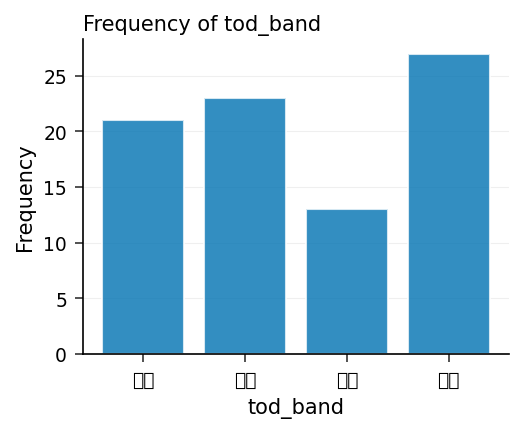

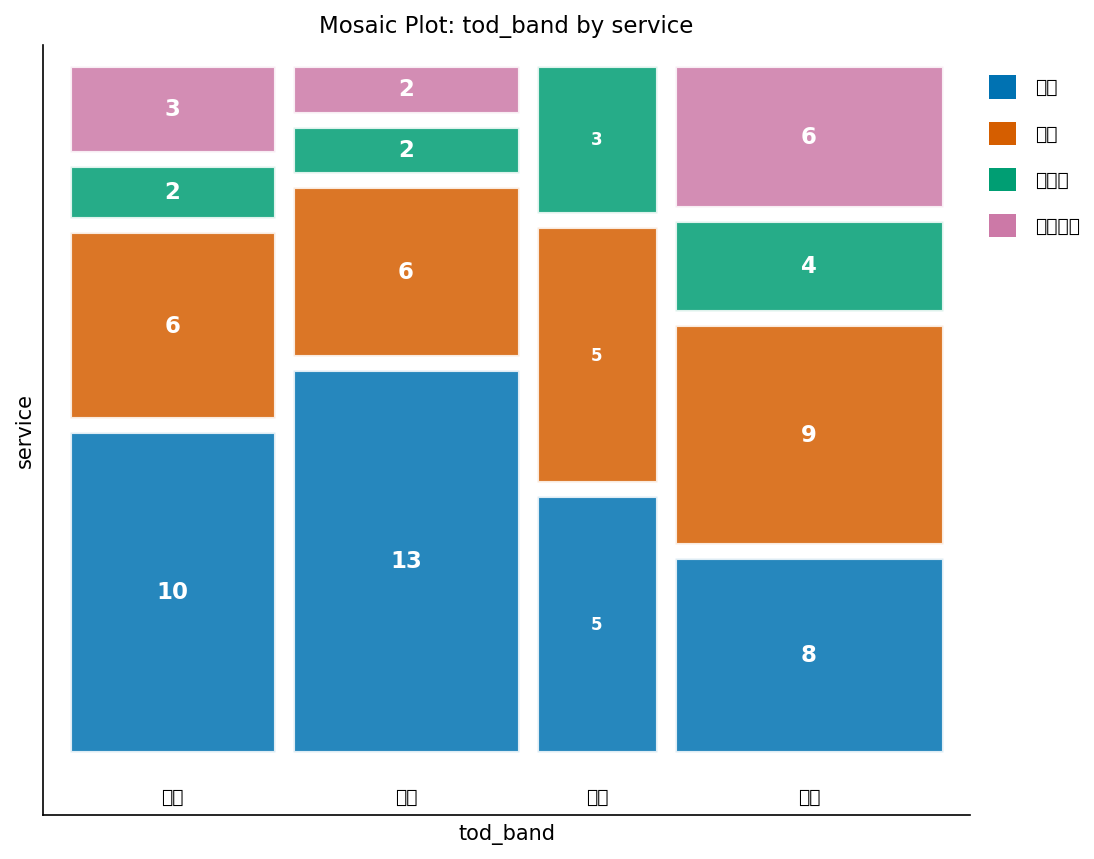

In [2]:
过程 频率 数据=ed;
    TABLES tod_band / nocum;
    TABLES tod_band*service / norow nocol nopercent;
    标签 tod_band='到达时段' service='收治科室';
    标题 '按一天中时段划分的急诊科入院到达情况';
运行;

## 3. 按收治科室分列的滞留负担（PROC MEANS）

哪个科室承担了最重的滞留负荷？我们按收治科室汇总滞留小时数，在离散程度之外报告均值和最大值（一个粗略的尾部指标）。均值与最大值之间的差距预示了分位数模型将精确量化的内容。

In [3]:
过程 均值 数据=ed n mean std MIN MAX maxdec=2;
    分类 service;
    变量 boarding_hrs;
    标签 service='收治科室' boarding_hrs='滞留时间（小时）';
    标题 '按收治科室划分的滞留时间（小时）';
运行;

                                                    按收治科室划分的滞留时间（小时）                                                    

                                                  The MEANS Procedure

                               Analysis Variable : boarding_hrs 滞留时间（小时）

        收治科室                  N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        内科                       36           5.90           2.11           2.70          12.70
        外科                       26           5.79           2.10           2.90          12.00
        心内科                      11           6.02           2.04           4.10          11.40
        重症监护                     11           8.04           1.80           5.70          12.50
        ---------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. 滞留小时数的分位数回归（PROC QUANTREG）

现在进入核心分析。我们在 **0.5、0.75、0.9 和 0.95 分位数**处，将**滞留小时数**对中心化的住院人数、一天中的时段以及收治科室进行回归。如果住院人数的斜率随着我们向上移动分位数而增大，那便是直接证据，说明床位压力对最坏情况患者的惩罚远甚于典型患者——这正是拥堵的标志。

因为 QUANTREG 是一个交互式（RUN-group）过程，我们以 `run;` 然后 `quit;` 结束该单元，使内核在此处刷新其输出。我们使用 `SEED=` 以获得可重现的稀疏法置信区间，并将每个分位数的参数估计写入一个 `OUTEST=` 数据集，后续单元将读取该数据集以直接比较各分位数间的住院人数斜率。

In [4]:
过程 quantreg 数据=ed ci=sparsity seed=20260607
              outest=qrest PLOTS=none;
    分类 tod_band service;
    模型 boarding_hrs = census_c tod_band service
        / quantile=0.5 0.75 0.9 0.95;
    标签 boarding_hrs='滞留时间（小时）' census_c='中心化床位占用'
          tod_band='到达时段' service='收治科室';
运行;
QUIT;

                                                    按收治科室划分的滞留时间（小时）                                                    


The QUANTREG Procedure

Quantile: 0.5000
CI Method: SPARSITY
Dependent Variable: 滞留时间（小时）

Parameter           Estimate       StdErr        Lower        Upper
Intercept             4.3625       0.2244       3.9226       4.8024
中心化床位占用               0.1125       0.0090       0.0949       0.1301
TOD_BAND 下午           0.3750       0.2453      -0.1058       0.8558
TOD_BAND 夜间           1.3750       0.2386       0.9073       1.8427
TOD_BAND 傍晚           1.5625       0.2910       0.9921       2.1329
SERVICE 重症监护          1.9375       0.2999       1.3496       2.5254
SERVICE 心内科          -0.1125       0.2935      -0.6878       0.4628
SERVICE 内科            0.4500       0.2113       0.0358       0.8642
Intercept             4.9800       0.2212       4.5465       5.4135
中心化床位占用               0.1600       0.0088       0.1427       0.1773
TOD_BAND 下午           0.7400       0.2


NOTE: PROC QUANTREG data=ed

NOTE: PROC QUANTREG completed.


### 4a. 比较各分位数间的住院人数斜率

`OUTEST=` 数据集为每个拟合的分位数保存一行系数。将中心化住院人数系数按分位数列出，使尾部效应一目了然：一条从中位数攀升到 0.95 分位数的斜率意味着，每增加一张被占用的住院床位，会给那些等待时间已经最长的患者增加*更多*滞留时间。

In [5]:
过程 打印 数据=qrest noobs 标签;
    变量 _quantile_ census_c;
    标签 _quantile_ = '分位数'
          census_c   = '床位占用斜率（每床小时数）';
    标题 '住院人数对滞留的影响（按分位数）';
运行;

                                                    住院人数对滞留的影响（按分位数）                                                    

                          床位占用斜率（每床小时数）
                                 0.1125
                                   0.16
                                   0.19
                           0.2166666667




NOTE: PROC PRINT data=qrest

NOTE: PROC PRINT completed: 4 observations printed, 1 variables


## 5. 解读与运营杠杆

**分位数模型告诉我们什么。** 分位数回归将*典型的*滞留体验（中位数，0.5）与*危机*体验（0.9-0.95）区分开来。这个队列所展现的模式——也是你应在真实数据中寻找的模式——是一条**随分位数上升的住院人数斜率**。拟合的中心化住院人数系数从**中位数处每张占用床位 0.11 小时，攀升到 0.75 分位数处的 0.16、0.90 处的 0.19，以及 0.95 处的 0.22**（见 4a 中的各分位数表）。由于 0.95 处的斜率几乎是中位数处斜率的两倍，一家满员的医院并不只是把每个人的等待时间均匀地上移；它会不成比例地拉爆最糟糕的那些等待。将各分位数的住院人数斜率并排比较——而非单一的平均效应——正是使尾部可见且可量化的原因。

**负担在哪里。** PROC MEANS 按平均滞留时间对各科室排序：**重症监护 最高，为 8.04 小时**，远高于 心内科（6.02）、内科（5.90）和 外科（5.79）。但*尾部*讲述了一个与均值不同的故事：**内科 承担了单次最长的滞留事件，达 12.70 小时——均值到最大值的差距为 6.80 小时**，是所有科室中最宽的，外科（最大 12.00）和 重症监护（最大 12.50）紧随其后。因此，重症监护 是滞留可靠地偏长的地方，而 内科 是发生最严重个别突破的地方。两者都是提前出院查房、专用降级病床和床位前置方案的高收益目标——重症监护 针对持续负荷，内科 针对尾部控制。

**压力何时达到峰值。** PROC FREQ 显示已收治患者需求集中在夜间：**夜间 时段最繁忙，占入院的 32%（84 例中的 27 例）**，其次是 下午（27%）和 上午（25%）；傍晚 时段最清闲，为 15%。交叉制表证实夜间负荷偏重于科室——夜间 承担了除少数几例外的全部 重症监护 入院（11 例中的 6 例），此外还有 8 例 内科 和 9 例 外科 到达——因此床位周转最慢的窗口恰好与最重且最危急的流入相重合。

**运营要点。**

1. **依据住院人数而非平均等待触发激增方案。** 由于上分位数的住院人数斜率最陡（0.95 分位数处 0.22 小时/床，对比中位数处 0.11），住院人数阈值（例如 > 80 张占用床位）是尾部滞留的一个领先指标。在中位数移动*之前*就启用溢流容量，可防止 0.95 分位数处的突破。
2. **以两种方式针对重尾科室。** 将持续负荷缓解（降级病床、床位前置）集中于**重症监护**，它的均值最高；将尾部控制（提前出院查房、突破审查）集中于**内科**，它拥有最宽的均值到最大值差距。
3. **为夜间床位周转缺口配置人员。** FREQ 将 **夜间** 确定为需求峰值，恰与最慢的床位周转相重合；非工作时段的床位管理和环境服务覆盖直接针对 `tod_band` 效应，QUANTREG 模型证实该效应在 夜间 和 傍晚 时段增加的滞留时间最多。
4. **将 0.95 分位数作为 KPI 追踪。** 仅报告平均滞留会掩盖系统正在辜负的那些患者。监测第 95 百分位的滞留时间——及其 0.22 小时/床的住院人数斜率——使该指标与它所代表的患者安全风险保持一致。

*此处所有数字均来自用于演示的合成数据；在真实的急诊科数据上，同样的 QUANTREG / MEANS / FREQ 工作流会产出实际的斜率、科室排名和到达概况，从而驱动一项拥堵缓解计划。*